# 02 — Extraction automatisée

**Livrable n°2** — Benoit Girard

L'étape *Extract* du pipeline : collecter les publications des quatre sources **sans intervention manuelle**, télécharger les images, et écrire le tout en JSON.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))

from dotenv import load_dotenv

load_dotenv(RACINE / ".env")

from checkitai.logging_setup import setup_logging

setup_logging()

## 1. Une source en panne ne doit pas arrêter les autres

`collecte_sources` appelle chaque connecteur dans son propre `try/except` et tient un bilan : nombre de publications par source, `-1` en cas d'erreur. C'est ce bilan qui alimente ensuite l'indicateur « sources en échec » du plan de monitoring.

In [2]:
from checkitai.config import ExtractionConfig
from checkitai.extract import collecte_sources

publications, bilan = collecte_sources(ExtractionConfig())
print(f"{len(publications)} publications collectées")
bilan

2026-08-20 11:53:40 | INFO    | checkitai.extract | Extraction : démarrage de la source 'rss'


2026-08-20 11:53:40 | INFO    | checkitai.sources.rss | RSS : lecture du flux 'the_guardian' (https://www.theguardian.com/world/rss)


2026-08-20 11:53:40 | INFO    | checkitai.sources.rss | RSS : 45 publications recuperees depuis 'the_guardian'


2026-08-20 11:53:40 | INFO    | checkitai.sources.rss | RSS : lecture du flux 'bbc_news' (https://feeds.bbci.co.uk/news/world/rss.xml)


2026-08-20 11:53:40 | INFO    | checkitai.sources.rss | RSS : 27 publications recuperees depuis 'bbc_news'


...

2026-08-20 11:54:18 | INFO    | checkitai.sources.kaggle_fakeddit | Fakeddit : 24 publications chargées depuis fakeddit_sample.tsv (échantillon de démonstration)


2026-08-20 11:54:18 | INFO    | checkitai.extract | Extraction : source 'kaggle_fakeddit' -> 24 publications


2026-08-20 11:54:18 | INFO    | checkitai.extract | Extraction : 179 publications brutes au total


179 publications collectées


{'rss': 97, 'newsdata': 10, 'fakenewsnet': 48, 'kaggle_fakeddit': 24}

## 2. Ce que renvoie un connecteur

Tous les connecteurs produisent la **même structure**, quelle que soit l'origine. C'est ce qui permet à l'étape suivante de les traiter uniformément.

In [3]:
import pandas as pd

df_brut = pd.DataFrame(publications)
print("Colonnes :", list(df_brut.columns))
df_brut[["source", "source_type", "access_method"]].value_counts().to_frame("publications")

Colonnes : ['source', 'source_type', 'access_method', 'title', 'text', 'url', 'image_url', 'image_source', 'published_at', 'language', 'label', 'label_source']


,,,publications
source,source_type,access_method,
rss:the_guardian,rss,flux_rss,45
rss:bbc_news,rss,flux_rss,27
rss:abc_news,rss,flux_rss,25
fakenewsnet:politifact,dataset,telechargement_github,24
fakenewsnet:gossipcop,dataset,telechargement_github,24
fakeddit:fakenews,dataset,telechargement_kaggle,12
fakeddit:news,dataset,telechargement_kaggle,12
newsdata,api,api_rest,10


## 3. Télécharger les images, pas seulement leurs URL

Une URL d'image ne prouve rien : elle peut être morte, protégée, ou pointer vers une page HTML. Le pipeline **télécharge** donc chaque image et l'ouvre avec Pillow avant de la conserver. Trois contrôles, du moins cher au plus cher : type MIME annoncé, taille du fichier, puis décodage réel.

C'est le chemin du fichier obtenu qui est enregistré à côté du texte.

In [4]:
from checkitai.config import ImageConfig
from checkitai.images import telecharge_images

compteurs = telecharge_images(publications, ImageConfig())
compteurs

2026-08-20 11:54:40 | WARNING | checkitai.images | Image : téléchargement impossible (https://www.jornaldocomercio.com/_midias/png/2026/08/17/fotos_hotsite_opiniao_pr) : 404 Client Error: Not Found for url: https://www.jornaldocomercio.com/_midias/png/2026/08/17/fotos_hotsite_opiniao_prancheta_1_10393783-11992594.png


2026-08-20 11:54:42 | WARNING | checkitai.images | Image : type 'text/html' refusé pour https://web.archive.org/web/20170702174006im_/http://freedomcrossroads.us/wp-con


2026-08-20 11:54:42 | WARNING | checkitai.images | Image : téléchargement impossible (http://nationalreport.net/wp-content/uploads/2016/05/Target.jpg) : 404 Client Error: Not Found for url: https://nationalreport.net/wp-content/uploads/2016/05/Target.jpg


2026-08-20 11:54:44 | WARNING | checkitai.images | Image : type 'text/html' refusé pour https://web.archive.org/web/20170731052757im_/http://politicspaper.com/wp-conten


2026-08-20 11:54:46 | INFO    | checkitai.images | Images : 116 téléchargées, 4 échecs, 59 ignorées (3.5 Mo sur disque)


{'tentees': 120,
 'reussies': 116,
 'echouees': 4,
 'ignorees': 59,
 'octets': 3635480}

In [5]:
avec_fichier = [p for p in publications if p.get("image_path")]
print(f"{len(avec_fichier)} publications ont bien un fichier image")
exemple = avec_fichier[0]
print("Texte :", exemple["title"][:88])
print("Image :", exemple["image_path"])

116 publications ont bien un fichier image
Texte : More than 100 dead after goldmine collapses in Central African Republic
Image : data/raw/images/9b7c024c13d467b6.jpg


Le couple texte / image, affiché tel qu'il sera donné au modèle :

More than 100 dead after goldmine collapses in Central African Republic


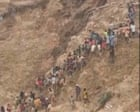

In [6]:
from IPython.display import Image, display
from checkitai.config import chemin_absolu

print(exemple["title"])
display(Image(filename=str(chemin_absolu(exemple["image_path"])), width=420))

## 4. Sauvegarde du brut

Le format retenu est le **JSON**, et non le CSV : une publication multimodale associe un texte et un chemin de fichier, et le JSON conserve cette structure sans ambiguïté. Le chemin enregistré est **relatif à la racine du projet**, pour rester valable ailleurs que sur la machine qui l'a produit — le pipeline tourne aussi bien en local que dans un conteneur Airflow.

In [7]:
import json
from checkitai.extract import save_raw

chemin_brut = save_raw(publications)
print("Écrit dans :", chemin_brut)
print(json.dumps(exemple, ensure_ascii=False, indent=2)[:600])

2026-08-20 11:54:46 | INFO    | checkitai.extract | Extraction : 179 publications écrites dans G:\Mon Drive\OC\Projet_12\checkitai\data\raw\raw_publications_20260820_095446.json


Écrit dans : G:\Mon Drive\OC\Projet_12\checkitai\data\raw\raw_publications_20260820_095446.json
{
  "source": "rss:the_guardian",
  "source_type": "rss",
  "access_method": "flux_rss",
  "title": "More than 100 dead after goldmine collapses in Central African Republic",
  "text": "<p>The collapse was caused by a landslide, while local officials say the death toll is likely to rise as recovery efforts continue</p><p>More than 100 people have died after an artisanal goldmine at a small village in western Central African Republic (CAR) caved in due to a landslide, local officials and aid workers said on Wednesday.</p><p>The landslide happened on Tuesday afternoon in the village of Zamboye, 
